# Problem Statement
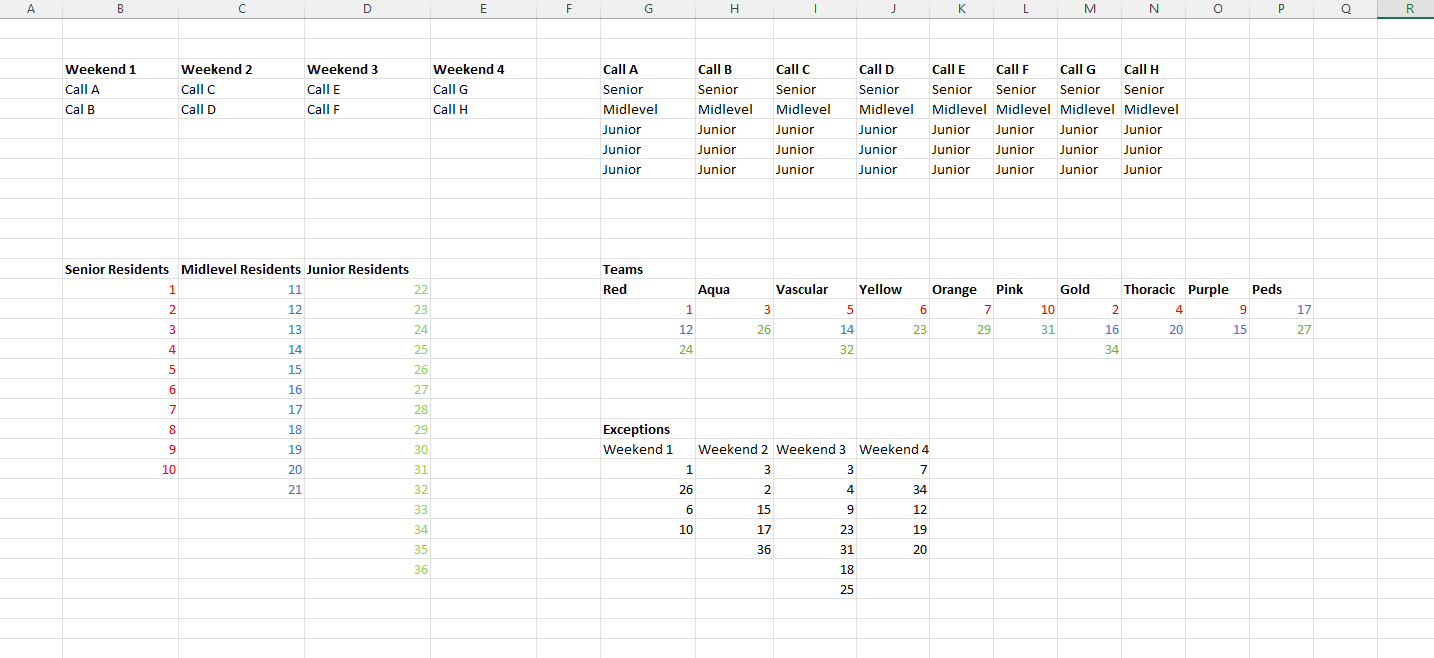



- Above you can see the basic breakdown of what we're looking at. 4 weekends a month with 2 calls each weekend. The breakdown of each call team is in the right upper hand. 5 total residents: 1 senior, 1-2 midlevel residents, and 2-3 junior residents

- There are several exceptions that need to be taken into account
  - The most basic rule is that senior residents must take 1 call shift a month, while midlevel and juniors must take two
  - There cannot be more than one senior on any given shift. If there are more seniors than call shift, then someone gets the month off of call
  The next exceptions are more complicated
  - On the right hand side you see the "Teams". Those are the resident teams that will require someone from the team to be working each weekend. So for each of those teams one of the members needs to be working one of the calls for every weekend
  - And in the bottom right there are "Exceptions" Those are the residents that cannot work that given weekend due to time off requests or vacation
  - You may be thinking the numbers dont add up because if a resident from each team needs to be on each weekend and the senior takes 1 call and the junior takes two that always leaves an uncovered weekend for the 2 person teams. But the senior resident also has one "rounding weekend" where they come in and round on the service but are not technically a part of the call team. So its another layer
  - The same resident CANNOT work both calls on the same weekend. So a junior resident cannot work both Call A and Call B. They have to work two SEPARATE weekends
  - You may be thinking the numbers dont add up because if a resident from each team needs to be on each weekend and the senior takes 1 call and the junior takes two that always leaves an uncovered weekend for the 2 person teams. But the senior resident also has one "rounding weekend" where they come in and round on the service but are not technically a part of the call team. So its another layer
- I imagine an app where you put in the configuration of your residency program and each resident gets a label ie senior, midlevel, junior. Then you put in the required composition of the call teams like I have in the spreadsheet
- Then each month you assign each resident to their team and input any exceptions for the month





## Install Libraries

In [20]:
!pip install ortools

# Load Data from CSV
- Residents CSV, Exceptions CSV, Teams CSV (not required we can have a team module that allows creation of teams from the pool)
- Need a method to identify research year mid-levels
- Need an input for call composition later.

In [44]:
import pandas as pd
# read residents, ensure in format: senior-midlevel-junior
residents_df = pd.read_csv("residents.csv")
s = residents_df.iloc[:, 0].dropna()
s = s.to_list()
for i in range(len(s)):
  s[i] = "S"+s[i]

m = residents_df.iloc[:, 1].dropna()
m = m.to_list()
for i in range(len(m)):
  m[i] = "M"+m[i]

j = residents_df.iloc[:, 2].dropna()
j = j.to_list()
for i in range(len(j)):
  j[i] = "J"+j[i]

print(s, m, j)



researchers = input("Enter Researcher IDs with comma separation ie. (1,2,3): ").strip().split(',')
for i in range(len(researchers)):
  researchers[i] = "M"+researchers[i].strip()
researchers = set(researchers)
print(f"{researchers=}")




s_max = len(s)
m_max = s_max + len(m)
j_max = m_max + len(j)
num_teams = int(input("Enter How many teams: ").strip())
teams = {}
for i in range(len(num_teams)):
  team_name = input(f"Enter team {i}: ")
  teams[team_name] = []
  members = input("Enter resident IDs ie. (1,14,22): ").strip().split(',')
  for id in members:
    if int(id) <= s_max:
      teams[team_name].append(f"S{id}")
    elif int(id) <= m_max:
      teams[team_name].append(f"M{id}")
    else:
      teams[team_name].append(f"J{id}")



['S1: Mesiti', 'S2: Applegarth', 'S3: Ward', 'S4: Nageeb', 'S5: LeMarbe', 'S6: Sobolic', 'S7: Baida', 'S8: Waleizer', 'S9: Haj Assad', 'S10: Robbe', 'S11: Aung', 'S12: Teitlebaum'] ['M13: Dowding', 'M14: Hurst', 'M15: Kowalczyk', 'M16: Rowland', 'M17: Najor', 'M18: Butler', 'M19: Davis'] ['J20: Awad', 'J21: Hunyadi', 'J22: Getzinger', 'J23: Faraj', 'J24: Brege', 'J25: Mohamadi', 'J26: Figge', 'J27: Gibbons', 'J28: Sancraint', 'J29: Sophia', 'J30: Sturtevant', 'J31: Tracy', 'J32: Vadnala', 'J33: Wolf', 'J34: Morrison', 'J35: Rotator 1', 'J36: Rotator 2', 'J37: Rotator 3', 'J38: Rotator 4']


KeyboardInterrupt: Interrupted by user

# Mock Data
- Exceptions, Teams, etc.



In [45]:
#Get input from user
s = input("Enter Senior IDs with comma separation ie. (1,2,3): ").strip().split(',')
for i in range(len(s)):
  s[i] = "S"+ s[i].strip()

m = input("Enter Mid-Level IDs with comma separation ie. (1,2,3): ").strip().split(',')
for i in range(len(m)):
  m[i] = "M"+ m[i].strip()

j = input("Enter Junior IDs with comma separation ie. (1,2,3): ").strip().split(',')
for i in range(len(j)):
  j[i] = "J"+ j[i].strip()

researchers = input("Enter Researcher IDs with comma separation ie. (1,2,3): ").strip().split(',')
for i in range(len(researchers)):
  researchers[i] = "M"+researchers[i].strip()
researchers = set(researchers)
print(f"{researchers=}")


#REAL TEST IDs
# 1,2,4,5,6,7,8,9,10,11,12
# 13,14,15,17,18,19
# 21,22,23,27,28,30,32,33,34,35,36,37,38

# 1,2,3,4,5,6,7,8,9,10
# 12,14,16,20,15,17,18,21,19
# 26,24,32,23,29,31,34,27,36,30,25,22,35

Enter Senior IDs with comma separation ie. (1,2,3):  1,2,4,5,6,7,8,9,10,11,12
Enter Mid-Level IDs with comma separation ie. (1,2,3): 13,14,15,17,18,19
Enter Junior IDs with comma separation ie. (1,2,3): 21,22,23,27,28,30,32,33,34,35,36,37,38
Enter Researcher IDs with comma separation ie. (1,2,3): 14,19
researchers={'M14', 'M19'}


In [46]:
print(len(s),len(m),len(j))
print(s,m,j)

11 6 13
['S1', 'S2', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9', 'S10', 'S11', 'S12'] ['M13', 'M14', 'M15', 'M17', 'M18', 'M19'] ['J21', 'J22', 'J23', 'J27', 'J28', 'J30', 'J32', 'J33', 'J34', 'J35', 'J36', 'J37', 'J38']


In [47]:
# -----------------------------
# Data
# -----------------------------
weekends = range(4)
calls = ["A", "B"]

# #Auto Gen Residents IDs
# s = ["S"+str(i) for i in range(1,11)]
# m = ["M"+str(i) for i in range(1,10)]
# j = ["J"+str(i) for i in range(1,14)]

residents = [] #The call pool
residents.extend(s)
residents.extend(m)
residents.extend(j)
print(f"{residents=}")
id_map = {r.split(':')[0]:r for r in residents}

teams = { #Define the teams
    "Red": ["S4","J22", "J32"],
    "Aqua": ["M17", "M18"],
    "Vascular": ["S10", "J37"],
    "Yellow": ["S5", "J34"],
    "Orange": ["S7", "J23"],
    "Pink": ["S1", "J27"],
    "Gold": ["S8", "M15","J35"],
    "Thoracic": ["S2", "J28","J36"],
    "Purple": ["S9", "J21"],
    "Peds": ["M13", "J30"],
}

# teams = { #Define the teams
#     "Red": ["S1","M12", "J24"],
#     "Aqua": ["S3", "J26"],
#     "Vascular": ["S5", "M14", "J32"],
#     "Yellow": ["S6", "J23"],
#     "Orange": ["S7", "J29"],
#     "Pink": ["S10", "J32"],
#     "Gold": ["S2", "M16","J34"],
#     "Thoracic": ["S4", "M20"],
#     "Purple": ["S9", "M15"],
#     "Peds": ["M17", "J27"],
# }
print(f"{teams=}")

roles = {} #For later counting
for r in residents:
    if r.startswith("S"):
      roles[r] = "senior"
    elif r.startswith("M") and r not in researchers:
      roles[r] = "mid"
    elif r.startswith("M") and r in researchers:
      roles[r] = "research"
    else:
      roles[r] = "junior"

print(f"{roles=}")


time_off = {
    ("S2", 0),
    ("S12", 0),
    ("J27", 0),
    ("J34", 0),

    ("S2", 1),
    ("S1", 1),
    ("S6", 1),

    ("M14", 2),
    ("J22", 2)
}

# for team, members in teams.items():
#   temp = []
#   for i in range(len(members)):
#     temp.append(id_map[members[i]])
#   teams[team] = temp
# temp = set()
# for id, w in time_off:
#   temp.add((id_map[id], w))
# time_off = temp


# Example: S1 cannot work weekend 1
# time_off = {
#     ("S1", 0),
#     ("J26", 0),
#     ("S6", 0),
#     ("S10", 0),

#     ("S3", 1),
#     ("S2", 1),
#     ("M15", 1),
#     ("M17", 1),
#     ("J36", 1),

#     ("S3", 2),
#     ("S4", 2),
#     ("S9", 2),
#     ("J23", 2),
#     ("J31", 2),
#     ("M18", 2),
#     ("J25", 2),

#     ("S7", 3),
#     ("J34", 3),
#     ("M12", 3),
#     ("M19", 3),
#     ("M20", 3),
# }

seniors = [r for r in residents if roles[r] == "senior"]

residents=['S1', 'S2', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9', 'S10', 'S11', 'S12', 'M13', 'M14', 'M15', 'M17', 'M18', 'M19', 'J21', 'J22', 'J23', 'J27', 'J28', 'J30', 'J32', 'J33', 'J34', 'J35', 'J36', 'J37', 'J38']
teams={'Red': ['S4', 'J22', 'J32'], 'Aqua': ['M17', 'M18'], 'Vascular': ['S10', 'J37'], 'Yellow': ['S5', 'J34'], 'Orange': ['S7', 'J23'], 'Pink': ['S1', 'J27'], 'Gold': ['S8', 'M15', 'J35'], 'Thoracic': ['S2', 'J28', 'J36'], 'Purple': ['S9', 'J21'], 'Peds': ['M13', 'J30']}
roles={'S1': 'senior', 'S2': 'senior', 'S4': 'senior', 'S5': 'senior', 'S6': 'senior', 'S7': 'senior', 'S8': 'senior', 'S9': 'senior', 'S10': 'senior', 'S11': 'senior', 'S12': 'senior', 'M13': 'mid', 'M14': 'research', 'M15': 'mid', 'M17': 'mid', 'M18': 'mid', 'M19': 'research', 'J21': 'junior', 'J22': 'junior', 'J23': 'junior', 'J27': 'junior', 'J28': 'junior', 'J30': 'junior', 'J32': 'junior', 'J33': 'junior', 'J34': 'junior', 'J35': 'junior', 'J36': 'junior', 'J37': 'junior', 'J38': 'junior'}


In [48]:
print(time_off, teams)

{('S12', 0), ('S2', 1), ('S6', 1), ('S1', 1), ('S2', 0), ('J27', 0), ('J22', 2), ('J34', 0), ('M14', 2)} {'Red': ['S4', 'J22', 'J32'], 'Aqua': ['M17', 'M18'], 'Vascular': ['S10', 'J37'], 'Yellow': ['S5', 'J34'], 'Orange': ['S7', 'J23'], 'Pink': ['S1', 'J27'], 'Gold': ['S8', 'M15', 'J35'], 'Thoracic': ['S2', 'J28', 'J36'], 'Purple': ['S9', 'J21'], 'Peds': ['M13', 'J30']}


# Build the Model

In [51]:
from ortools.sat.python import cp_model

def cp_resident_scheduler(residents, teams, weekends, calls, time_off, roles):
  model = cp_model.CpModel()
  # 1 set is our 4 week period
  # -----------------------------
  # Variables
  # -----------------------------
  x = {}
  for r in residents:
      for w in weekends:
          for c in calls:
              x[(r,w,c)] = model.NewBoolVar(f"x_{r}_{w}_{c}")
  # -----------------------------
  # Constraints
  # -----------------------------
  # 1. call composition
  for w in weekends:
    for c in calls:
      senior_count = sum(x[(r,w,c)] for r in residents if roles[r]=='senior') #how many seniors on call
      mid_count = sum(x[(r,w,c)] for r in residents if roles[r]=='mid')
      junior_count = sum(x[(r,w,c)] for r in residents if roles[r]=='junior')
      total_count = sum(x[(r,w,c)] for r in residents) # how many residents in total

      # Add the constraints, relaxed composition constraints to allow for manual adjustments.
      model.Add(senior_count==1) #Hard constraint on seniors only 1 per call
      model.Add(mid_count >=1)
      model.Add(mid_count <=2)
      model.Add(total_count >= 5)
      model.Add(total_count <= 7)
      model.Add(junior_count >= 2)
      model.Add(junior_count <= 4)
      model.Add(junior_count + mid_count >= 4)
      model.Add(junior_count + mid_count <= 6)

  # 2. Workload constraints
  for r in residents:
      total = sum(x[(r,w,c)] for w in weekends for c in calls)

      if roles[r] == "senior":
        model.Add(total <= 1)
      elif roles[r] == 'research':
        model.Add(total == 1)
      else:
        # model.Add(total >= 1)
        model.Add(total == 2) #enforce mid/junior works 2 calls/set

  # 3. No double-call weekends
  for r in residents:
      for w in weekends:
          model.Add(x[(r,w,"A")] + x[(r,w,"B")] <= 1)

  # 4. Time off
  for (r,w) in time_off:
      for c in calls:
          model.Add(x[(r,w,c)] == 0)

  # 5. Teams and Rounding
  # rounding variables
  team_seniors = {}
  for team, members in teams.items():
      for r in members:
          if roles[r] == "senior":
              team_seniors[team] = r
              break

  # Choose if the senior rounds the week
  y = {}
  for s in seniors:
      for w in weekends:
          y[(s,w)] = model.NewBoolVar(f"round_{s}_{w}")
          if (s,w) in time_off:
            model.Add(y[(s,w)] == 0) #senior cannot round when they are off.

  # senior cannot both work and round
  for s in seniors:
      for w in weekends:
          model.Add(
              sum(x[(s,w,c)] for c in calls) + y[(s,w)] <= 1
          )

  # limit rounding frequency
  for s in seniors:
      model.Add(sum(y[(s,w)] for w in weekends) <= 1)


  # team coverage
  for w in weekends:
      for team, members in teams.items():
          team_has_call = sum(
              x[(r,w,c)]
              for r in members
              for c in calls
          )
          senior_cover = sum(
              y[(s,w)]
              for s in seniors
              if s in members
          )
          model.Add(team_has_call + senior_cover >= 1)

  # -----------------------------
  # Solve/Output
  # -----------------------------
  solver = cp_model.CpSolver()
  solver.parameters.linearization_level = 0
  # Enumerate all solutions.
  # solver.parameters.enumerate_all_solutions = True
  solver.parameters.max_time_in_seconds = 45
  result = solver.Solve(model)
  if result == cp_model.FEASIBLE:
    print("Found a solution")
  elif result == cp_model.OPTIMAL:
    print("Optimal solution")
  elif result == cp_model.INFEASIBLE:
    print("No solution exists")
  else:
    print("Unknown (might exist, not found yet)")

  if result == cp_model.OPTIMAL or result == cp_model.FEASIBLE:
    for w in weekends:
      print(f"\nWeekend {w+1}")
      for c in calls:
        assigned = [r for r in residents if solver.Value(x[(r,w,c)]) == 1]
        print(f"  Call {c}: {assigned}")
      rounding = [s for s in seniors if solver.Value(y[(s,w)]) == 1]
      print(f"Rounding: {rounding}")

  return result, solver


result, solver = cp_resident_scheduler(residents=residents,
                                       teams=teams,
                                       weekends=weekends,
                                       calls=calls,
                                       time_off=time_off,
                                       roles=roles)

Optimal solution

Weekend 1
  Call A: ['S5', 'M13', 'J21', 'J23', 'J33', 'J36']
  Call B: ['S8', 'M17', 'J22', 'J37', 'J38']
Rounding: ['S1']

Weekend 2
  Call A: ['S4', 'M18', 'J22', 'J23', 'J30']
  Call B: ['S10', 'M14', 'M15', 'J27', 'J28', 'J34']
Rounding: ['S9']

Weekend 3
  Call A: ['S9', 'M17', 'J34', 'J35', 'J36']
  Call B: ['S1', 'M15', 'J30', 'J32', 'J33']
Rounding: ['S7', 'S10']

Weekend 4
  Call A: ['S7', 'M18', 'M19', 'J27', 'J32', 'J35', 'J37']
  Call B: ['S12', 'M13', 'J21', 'J28', 'J38']
Rounding: ['S5']


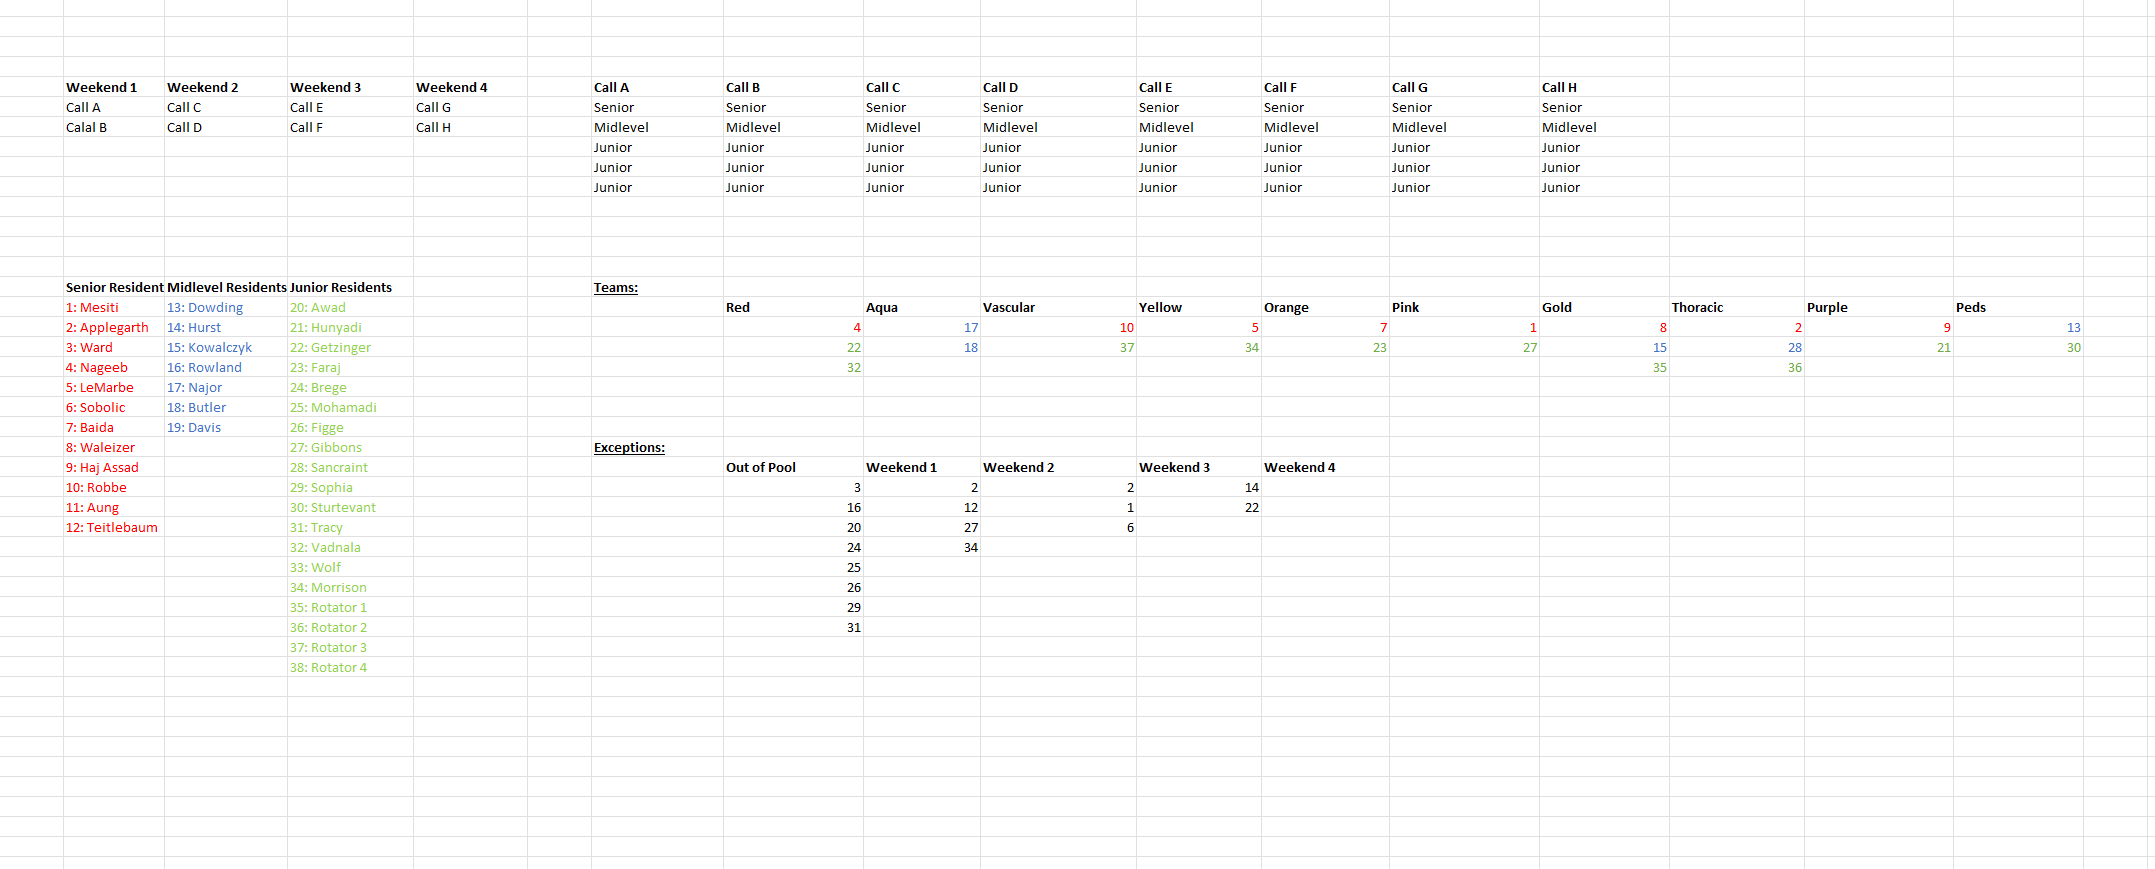